In [1]:
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import joblib

# Remove other target columns and other model predictions
cols_to_drop = ["hospdead", "slos", "charges", "totcst", "totmcst", "avtisst", "sfdm2",
                "adlp", "adls", "dzgroup",  # "adlp", "adls", and "dzgroup" were used in other preprocessing steps,
                # see https://github.com/autonlab/auton-survival/blob/master/auton_survival/datasets.py
                "sps", "aps", "surv2m", "surv6m", "prg2m", "prg6m", "dnr", "dnrday", "hday"]

# `death` is the overall survival event indicator
# `d.time` is the time to death from any cause or censoring
df_full = (pd.read_csv('support2csv.zip').drop(cols_to_drop, axis=1).rename(columns={"d.time": "time", "death": "event"}))
df_full["event"] = df_full["event"].astype(int)
df_full["ca"] = (df_full["ca"] == "metastatic").astype(int)

# use recommended default values from official dataset description ()
# or mean (for continuous variables)/mode (for categorical variables) if not given
fill_vals = {
    "alb": 3.5,
    "pafi": 333.3,
    "bili": 1.01,
    "crea": 1.01,
    "bun": 6.51,
    "wblc": 9,
    "urine": 2502,
    "edu": df_full["edu"].mean(),
    "ph": df_full["ph"].mean(),
    "glucose": df_full["glucose"].mean(),
    "scoma": df_full["scoma"].mean(),
    "meanbp": df_full["meanbp"].mean(),
    "hrt": df_full["hrt"].mean(),
    "resp": df_full["resp"].mean(),
    "temp": df_full["temp"].mean(),
    "sod": df_full["sod"].mean(),
    "income": df_full["income"].mode()[0],
    "race": df_full["race"].mode()[0],
}
df_full = df_full.fillna(fill_vals)

df_full.sex.replace({'male': 1, 'female': 0}, inplace=True)
df_full.income.replace({'under $11k': 0, '$11-$25k': 1, '$25-$50k': 2, '>$50k': 3}, inplace=True)
skip_cols = ['event', 'sex', 'time', 'dzclass', 'race', 'diabetes', 'dementia', 'ca']
cols_standardize = list(set(df_full.columns.to_list()).symmetric_difference(skip_cols))

# one-hot encode categorical variables
onehot_cols = ["dzclass", "race"]
df_full = pd.get_dummies(df_full, columns=onehot_cols, drop_first=True)
df_full = df_full.rename(columns={"dzclass_COPD/CHF/Cirrhosis": "dzclass_COPD"})

(array([4363.,  763.,  391.,  228.,  163.,  110.,   83.,   57.,   27.,
          16.]),
 array([   3. ,  197.1,  391.2,  585.3,  779.4,  973.5, 1167.6, 1361.7,
        1555.8, 1749.9, 1944. ]),
 <BarContainer object of 10 artists>)

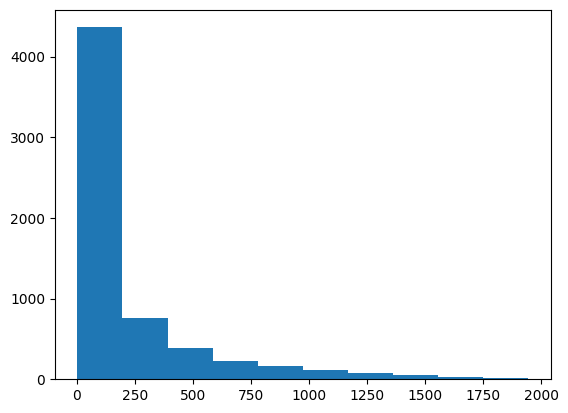

In [2]:
import matplotlib.pyplot as plt

plt.hist(df_full[df_full['event'] == 1]['time'])

(array([4.682e+03, 1.000e+00, 3.080e+02, 1.710e+02, 4.390e+02, 8.400e+01,
        1.070e+02, 0.000e+00, 4.900e+01, 3.600e+02]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

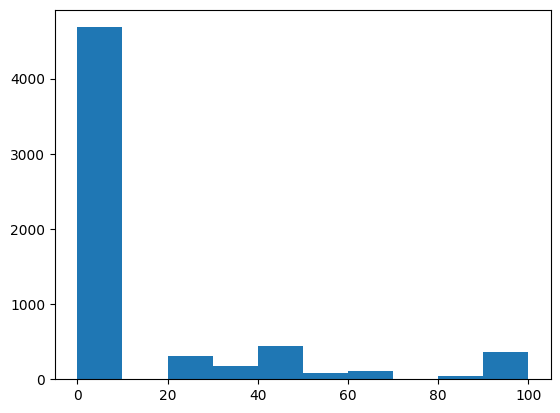

In [3]:
plt.hist(df_full[df_full['event'] == 1]['scoma'])

(array([5.787e+03, 2.030e+02, 7.800e+01, 5.900e+01, 3.500e+01, 1.700e+01,
        1.000e+01, 7.000e+00, 4.000e+00, 1.000e+00]),
 array([ 0.09999084,  6.38999176, 12.67999267, 18.96999359, 25.2599945 ,
        31.54999542, 37.83999634, 44.12999725, 50.41999817, 56.70999908,
        63.        ]),
 <BarContainer object of 10 artists>)

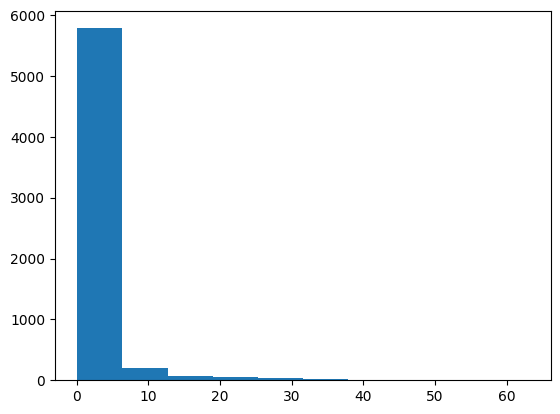

In [4]:
plt.hist(df_full[df_full['event'] == 1]['bili'])

In [5]:
import numpy as np
import pandas as pd
import joblib
import os
from sklearn.model_selection import train_test_split

def get_covariate_censor_fn(hospital_type):
    if hospital_type == 'high_resource':
        return lambda row: row['scoma'] > 30 or row['bili'] > 1.0 or row['crea'] > 1.2 or row['meanbp'] < 80 or row['alb'] < 3.4
    elif hospital_type == 'moderate_resource':
        return lambda row: row['scoma'] > 40 or row['bili'] > 1.5 or row['crea'] > 1.5 or row['meanbp'] < 70 or row['alb'] < 3.0
    elif hospital_type == 'low_resource':
        return lambda row: row['scoma'] > 60 or row['bili'] > 2.5 or row['crea'] > 2.0 or row['meanbp'] < 60 or row['alb'] < 2.5
    else:
        raise ValueError(f"Unknown hospital type: {hospital_type}")

def apply_censoring_and_save_binned(df_full, strategy='outcome', thresholds=[60, 70, 80], hospital_types=['low_resource', 'moderate_resource', 'high_resource']):
    base_dir = "/data4/meerak/support50_propbin_data"
    os.makedirs(base_dir, exist_ok=True)

    # Build param list for iteration
    if strategy == 'hybrid':
        param_list = [(t, h) for t in thresholds for h in hospital_types]
    else:
        param_list = thresholds if strategy == 'outcome' else hospital_types

    for param in param_list:
        newX = df_full[df_full['event'] == 1].copy()

        # Apply censoring
        if strategy == 'outcome':
            suffix = f"{strategy}_T{param}"
            TTE_threshold = np.percentile(newX['time'], param)
            newX['updated_event'] = (newX['time'] > TTE_threshold).astype(int)

        elif strategy == 'covariate':
            suffix = f"{strategy}_{param}"
            censor_fn = get_covariate_censor_fn(param)
            newX['updated_event'] = newX.apply(lambda row: 1 - int(censor_fn(row)), axis=1)

        elif strategy == 'hybrid':
            threshold, hospital_type = param
            suffix = f"{strategy}_T{threshold}_{hospital_type}"
            TTE_threshold = np.percentile(newX['time'], threshold)
            censor_fn = get_covariate_censor_fn(hospital_type)

            def hybrid_fn(row):
                if row['time'] <= TTE_threshold:
                    return censor_fn(row)
                return False

            newX['updated_event'] = newX.apply(lambda row: 1 - int(hybrid_fn(row)), axis=1)

        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        # Bin time
        K = 50
        try:
            newX['binned_time'], bins = pd.cut(newX['time'], bins=K, labels=False, retbins=True, duplicates='drop')
        except ValueError:
            newX['binned_time'] = 0

        # print(np.median(newX['binned_time']).item())
        delta = np.median(newX['binned_time']).item() + np.median(newX['binned_time']).item()*np.random.rand(len(newX))
        
        newX['observed_time'] = np.where((newX['updated_event'] == 0) & (delta < newX['binned_time']), delta, newX['binned_time'])

        newX['updated_event']= (newX['updated_event'] == 0) & (delta < newX['binned_time'])
        print(suffix, sum(newX['updated_event']), len(newX['updated_event']))
        newX['binned_time'] = newX['binned_time'].astype(int)
        newX['observed_time'] = newX['observed_time'].astype(int)
        
        # for i in range(len(bins) - 1):
        #     bin_start = bins[i]
        #     bin_end = bins[i+1]
        #     bin_times = newX[(newX['time'] >= bin_start) & (newX['time'] <= bin_end)]
        #     print(f"Bin {i}: time ∈ [{bin_start:.2f}, {bin_end:.2f}], count = {len(bin_times)}")
        # print()
        # print()

        newX[cols_standardize] = newX[cols_standardize].apply(lambda x: (x - x.mean()) / x.std())
        # Split into train/val/test
        train_df, temp_df = train_test_split(newX, test_size=0.4, random_state=42)
        val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

        for split_name, df in zip(["train", "val", "test"], [train_df, val_df, test_df]):
            X = df.drop(columns=['time', 'event', 'updated_event', 'observed_time', 'binned_time'])
            orig_y = df['binned_time']
            y = df['observed_time']
            binary_y = df['updated_event']
            joblib.dump(X.to_numpy(dtype=float), os.path.join(base_dir, f"X_{split_name}_{suffix}.joblib"))
            joblib.dump(orig_y.to_numpy(dtype=int), os.path.join(base_dir, f"orig_y_{split_name}_{suffix}.joblib"))
            joblib.dump(y.to_numpy(dtype=int), os.path.join(base_dir, f"y_{split_name}_{suffix}.joblib"))
            joblib.dump(binary_y.to_numpy(dtype=int), os.path.join(base_dir, f"binary_y_{split_name}_{suffix}.joblib"))

            # print(X.shape)
            # print(list(set(y)))
            
apply_censoring_and_save_binned(df_full, strategy='covariate')


outcome_T20 0 6201
outcome_T40 0 6201
outcome_T60 287 6201
outcome_T80 1520 6201
covariate_low_resource 1118 6201
covariate_moderate_resource 1755 6201
covariate_high_resource 2465 6201
